# Astana Apartment Price Prediction (krisha.kz)

## Objective

The goal of this study is to predict apartment listing prices in Astana from a compact set of structured features available in a saved krisha.kz snapshot. The workflow is organized as a supervised regression problem with a strict separation between model selection on the training data and final evaluation on an untouched holdout test set.

The notebook follows five steps:

1. inspect and clean the raw snapshot,
2. study target and feature distributions through exploratory analysis,
3. compare baseline model families on the training split,
4. tune the strongest candidates with cross-validation,
5. evaluate the final candidates on the holdout test set and analyze error by price segment.

The emphasis is on a leakage-safe pipeline, transparent model comparison, and interpretation of results in the context of a small, heterogeneous housing dataset.

In [1]:
from pathlib import Path
import json
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import randint, uniform, loguniform

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import KFold, RandomizedSearchCV, cross_validate, train_test_split
from xgboost import XGBRegressor

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.project_utils import (
    RAW_FEATURE_COLUMNS,
    build_app_metadata,
    make_pipeline,
    make_pipeline_log,
    prepare_base,
)

RANDOM_STATE = 42
DATA_PATH = PROJECT_ROOT / "data" / "krisha_data.csv"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

## 1. Load the raw data snapshot

The analysis starts from a stored table of apartment listings rather than from collection code. The raw snapshot contains 3,006 rows and 11 columns, including district, building type (tip_doma), year, floor, area, room count, several categorical apartment attributes, and the listing price.

This is a compact feature set for a housing-price task. It contains several variables that are usually informative for price, but it does not capture the full set of market drivers such as exact geolocation, building amenities, renovation quality beyond coarse labels, view, seller strategy, or micro-neighborhood effects. That limitation is important for interpreting later model performance.

In [2]:
df_raw = pd.read_csv(DATA_PATH)
print(df_raw.shape)
df_raw.head()

(3006, 11)


,district,tip_doma,jk,year,floor,area,toilet,parking,status,num_rooms,price
0,Нура,монолитный,Tumar Club,2025,9.0,41.27 м²,NaN,NaN,черновая отделка,1,31 000 000〒
1,Нура,монолитный,Turan Life,2023,16.0,41.7 м²,NaN,NaN,свежий ремонт,1,30 500 000〒
2,Нура,монолитный,Dastur,2024,7.0,58 м²,совмещенный,NaN,NaN,2,42 500 000〒
3,Байконур,монолитный,Фаворит,2013,8.0,"87 м², Площадь кухни — 24 м²",NaN,NaN,свежий ремонт,2,42 000 000〒
4,NaN,монолитный,Arena Garden,2025,11.0,30 м²,NaN,NaN,свежий ремонт,1,27 500 000〒


## 2. Clean the snapshot

The cleaning stage creates a reliable modeling table before any train/test split is defined. Exact duplicate rows are removed, the target is parsed from the original string format into numeric tenge values, area is extracted from the text field, several numeric columns are coerced to numeric form, and district labels are standardized.

At this stage the goal is not to create model-specific signals but to establish a consistent base table. Feature engineering that should be reproduced during inference is deferred to the pipeline so that training and prediction use the same transformations.

In [3]:
df = prepare_base(df_raw)

summary = {
    "raw_rows": int(len(df_raw)),
    "rows_after_dedup_and_target_cleaning": int(len(df)),
    "exact_duplicates_removed": int(df_raw.duplicated().sum()),
    "rows_with_missing_target_removed": int(df_raw["price"].isna().sum()),
}
summary

{'raw_rows': 3006,
 'rows_after_dedup_and_target_cleaning': 2357,
 'exact_duplicates_removed': 343,
 'rows_with_missing_target_removed': 370}

### Data quality summary

The cleaning output shows that the raw snapshot contains 3,006 rows, of which 343 are exact duplicates. Another 370 rows have missing or invalid target values and are removed before modeling, leaving 2,357 usable observations. This is a material reduction in size, so later performance should be interpreted in the context of a fairly small final sample rather than the original raw row count.

## 3. Exploratory data analysis

The exploratory stage focuses on the variables that are most likely to shape price and on the distributional issues that matter for regression. In housing data, broad value ranges, right-skewed targets, and strong heterogeneity across submarkets are common, so the EDA is used to assess whether a simple linear structure is sufficient and whether a transformed target is justified.

A log-transformed view of price is included because the raw target spans a very wide range and contains a long upper tail. This is especially relevant later, since the notebook compares models on both the original price scale and a log-transformed target.

In [4]:
df[["price", "area", "floor", "year", "num_rooms"]].describe().T

,count,mean,std,min,25%,50%,75%,max
price,2357.0,4.886233e+07,4.572342e+07,4850000.0,26500000.0,37500000.0,56000000.0,785000000.0
area,2357.0,7.266435e+01,4.043767e+01,13.0,44.4,63.0,87.1,504.0
floor,2341.0,6.960273e+00,4.322338e+00,1.0,4.0,6.0,9.0,36.0
year,2357.0,2.018082e+03,9.800757e+00,1959.0,2015.0,2021.0,2025.0,2027.0
num_rooms,2357.0,2.345354e+00,1.010321e+00,1.0,2.0,2.0,3.0,10.0


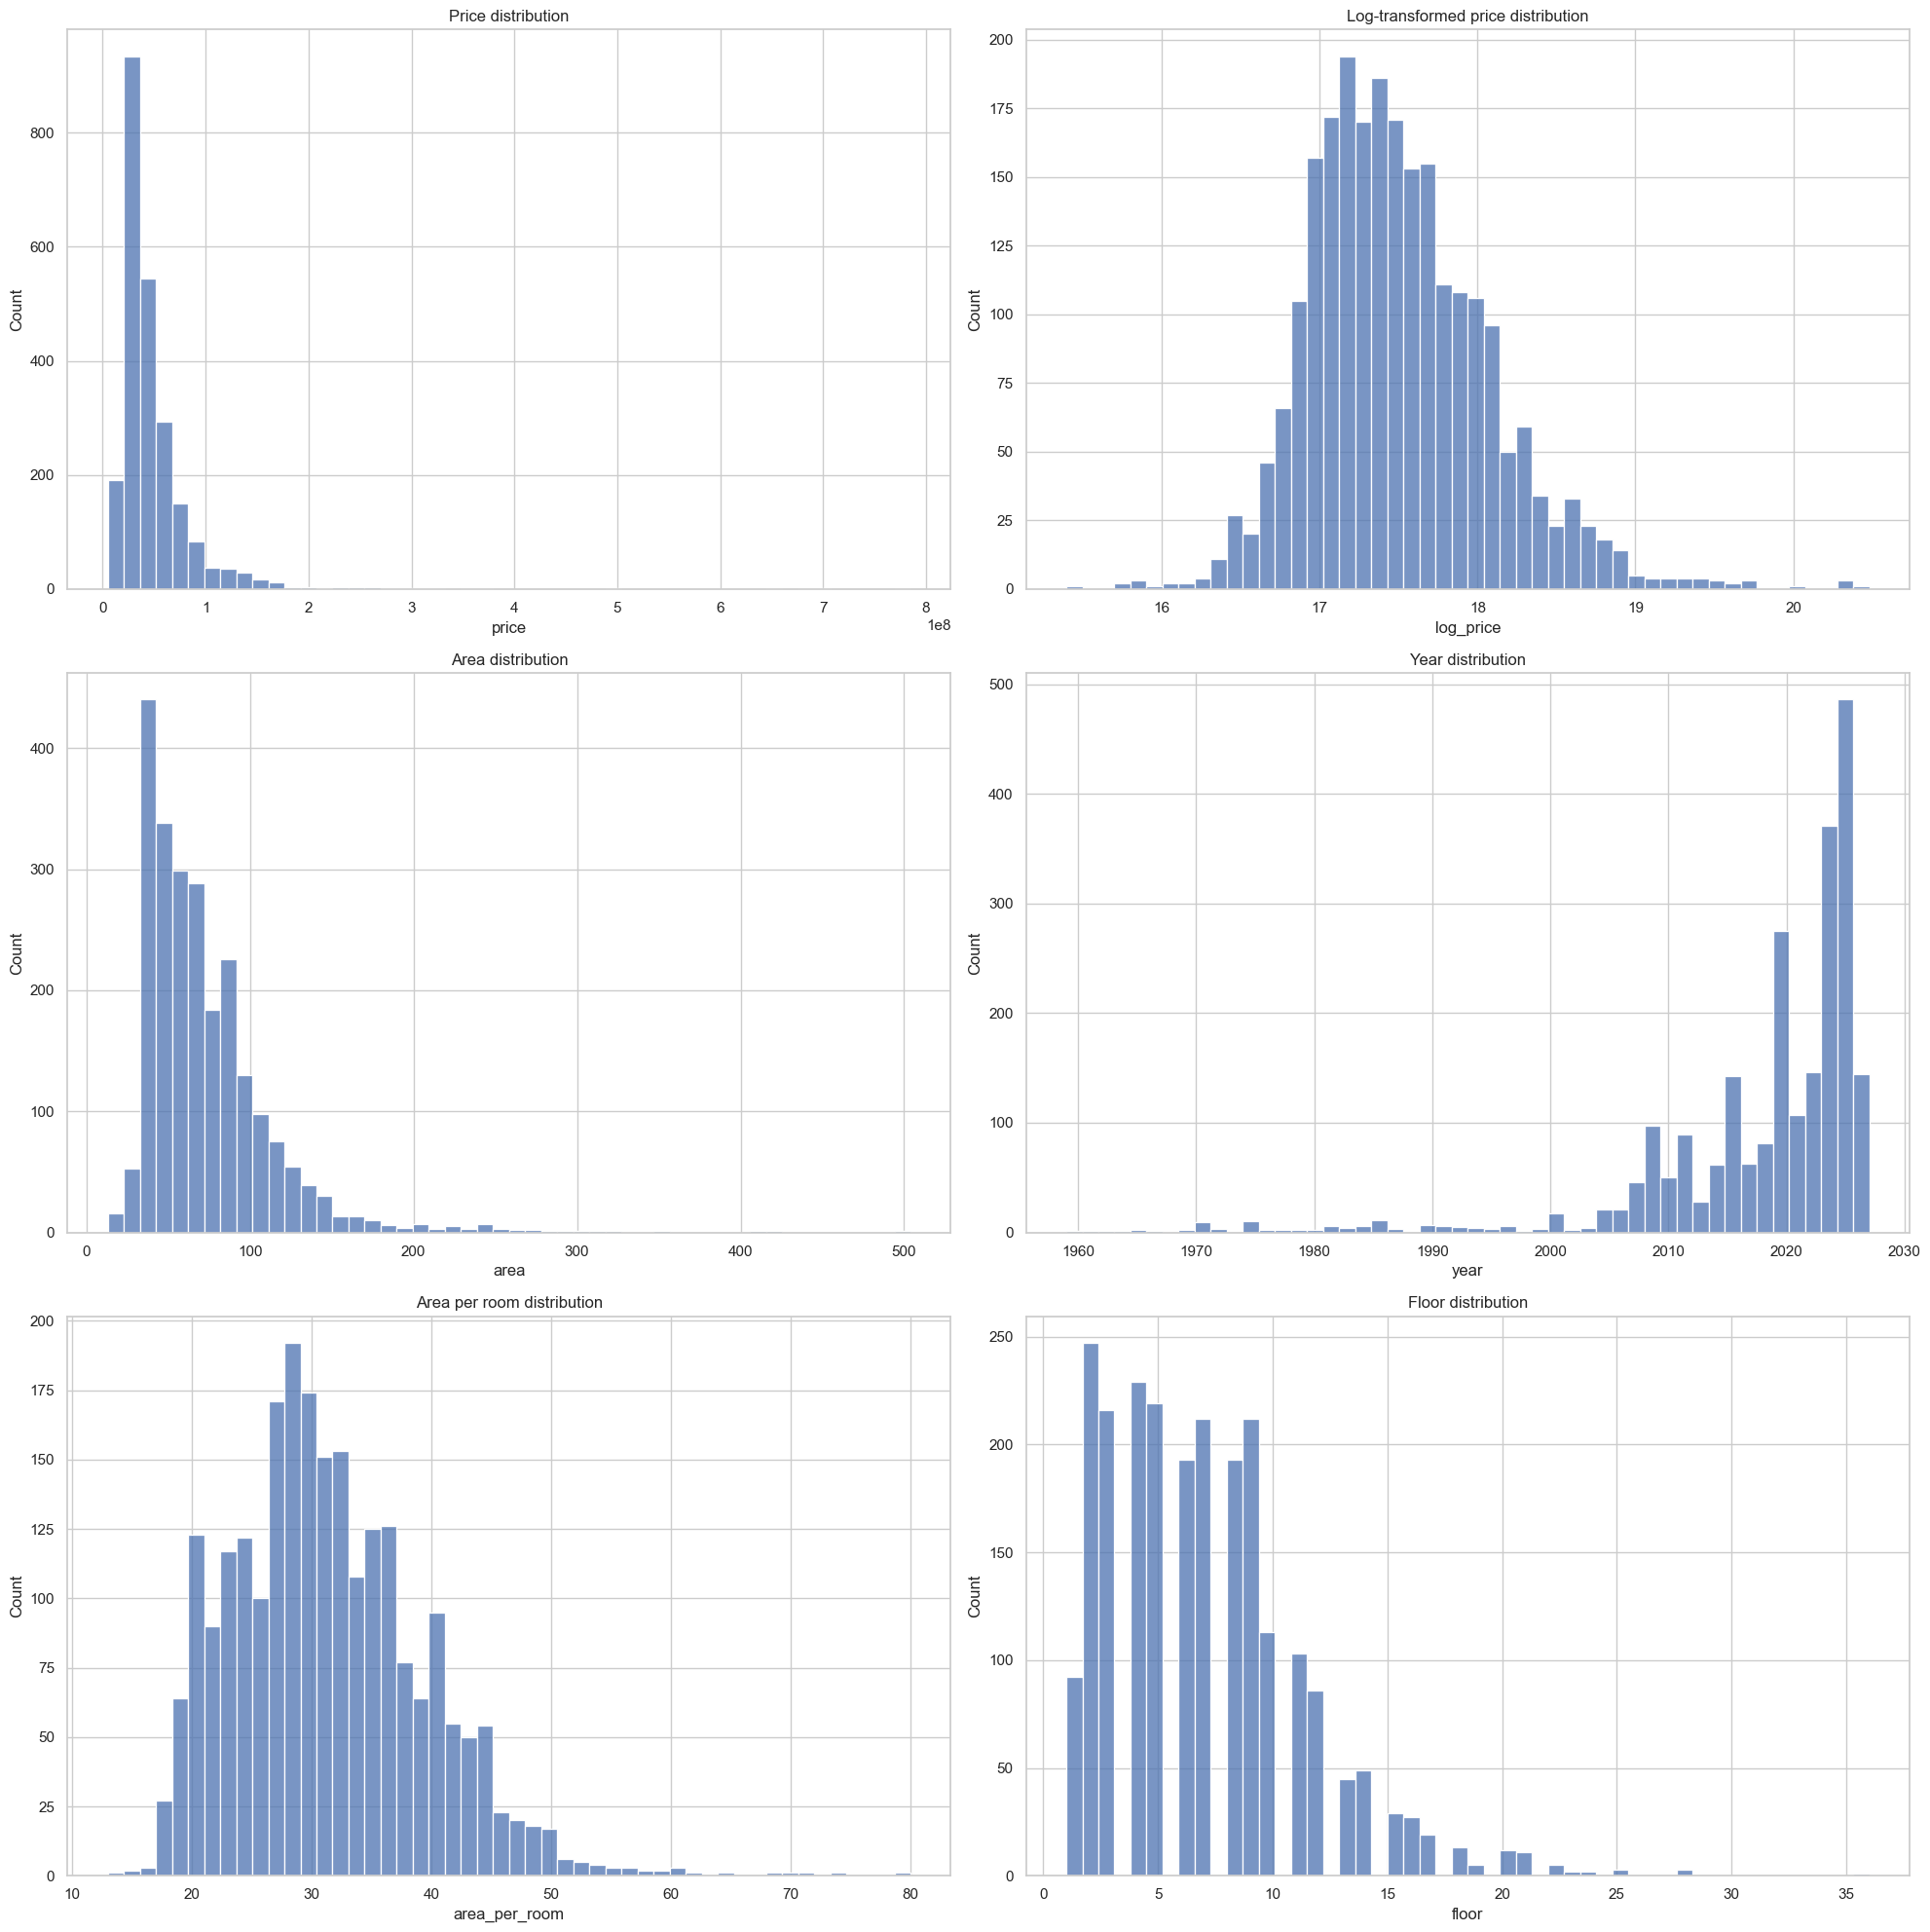

In [5]:
# EDA copy so we do not accidentally modify the modeling dataframe
eda_df = df.copy()

eda_df["log_price"] = np.log1p(eda_df["price"])
eda_df["area_per_room"] = eda_df["area"] / eda_df["num_rooms"].replace(0, np.nan)

fig, axes = plt.subplots(3, 2, figsize=(20, 20))
axes = axes.flatten()

sns.histplot(eda_df["price"], bins=50, ax=axes[0])
axes[0].set_title("Price distribution")

sns.histplot(eda_df["log_price"], bins=50, ax=axes[1])
axes[1].set_title("Log-transformed price distribution")

sns.histplot(eda_df["area"], bins=50, ax=axes[2])
axes[2].set_title("Area distribution")

sns.histplot(eda_df["year"], bins=50, ax=axes[3])
axes[3].set_title("Year distribution")

sns.histplot(eda_df["area_per_room"].dropna(), bins=50, ax=axes[4])
axes[4].set_title("Area per room distribution")

sns.histplot(eda_df['floor'], bins=50, ax=axes[5])
axes[5].set_title("Floor distribution")

plt.tight_layout()
plt.show()

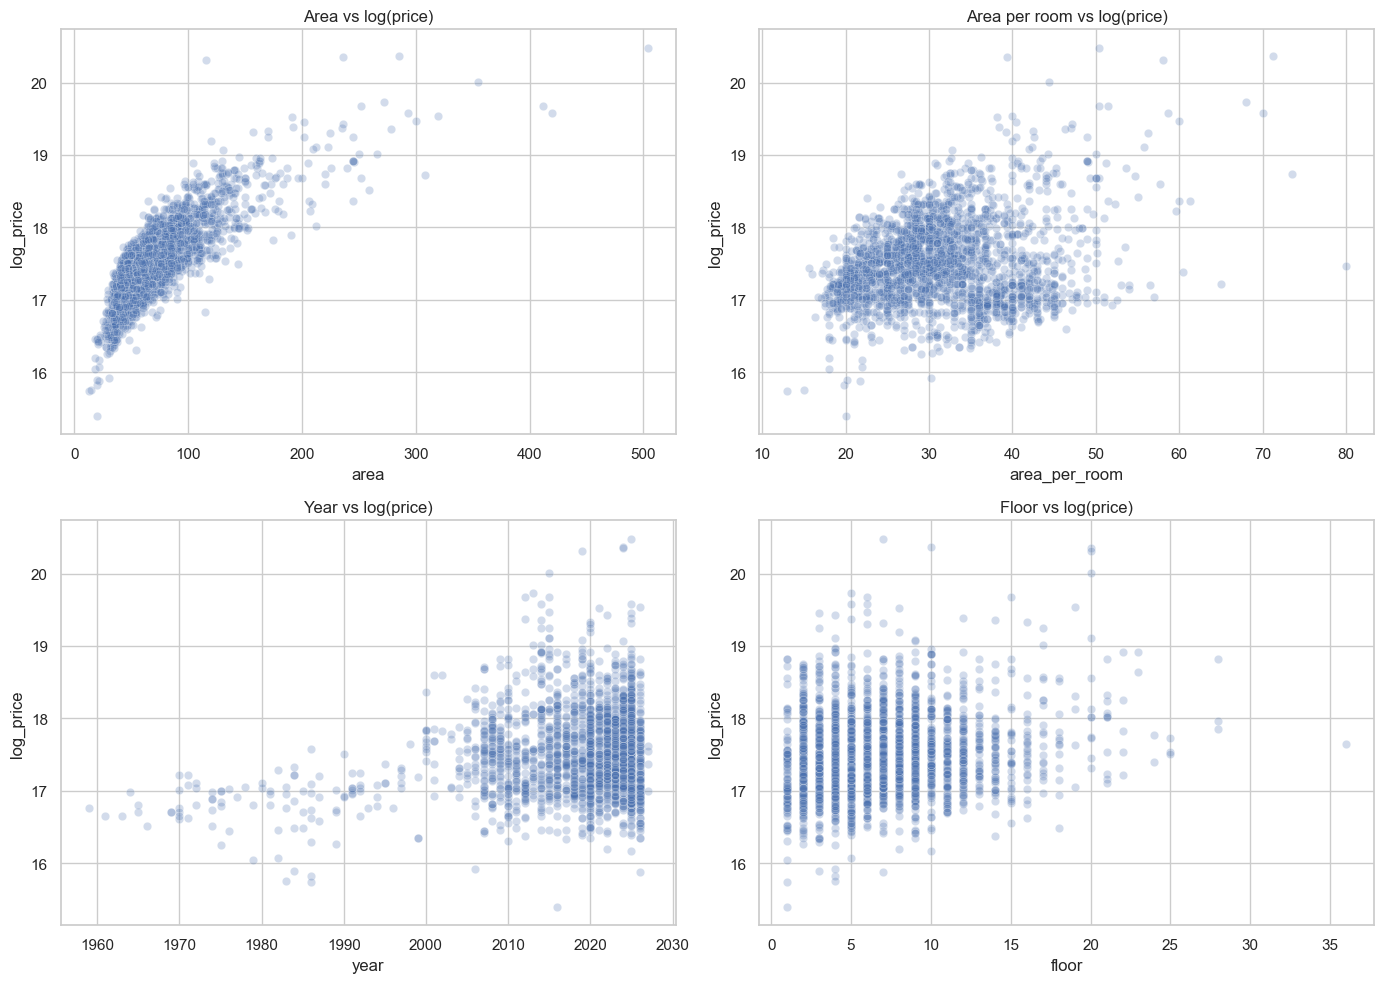

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(data=eda_df, x="area", y="log_price", alpha=0.25, ax=axes[0, 0])
axes[0, 0].set_title("Area vs log(price)")

sns.scatterplot(data=eda_df, x="area_per_room", y="log_price", alpha=0.25, ax=axes[0, 1])
axes[0, 1].set_title("Area per room vs log(price)")

sns.scatterplot(data=eda_df, x="year", y="log_price", alpha=0.25, ax=axes[1, 0])
axes[1, 0].set_title("Year vs log(price)")

sns.scatterplot(data=eda_df, x="floor", y="log_price", alpha=0.25, ax=axes[1, 1])
axes[1, 1].set_title("Floor vs log(price)")

plt.tight_layout()
plt.show()

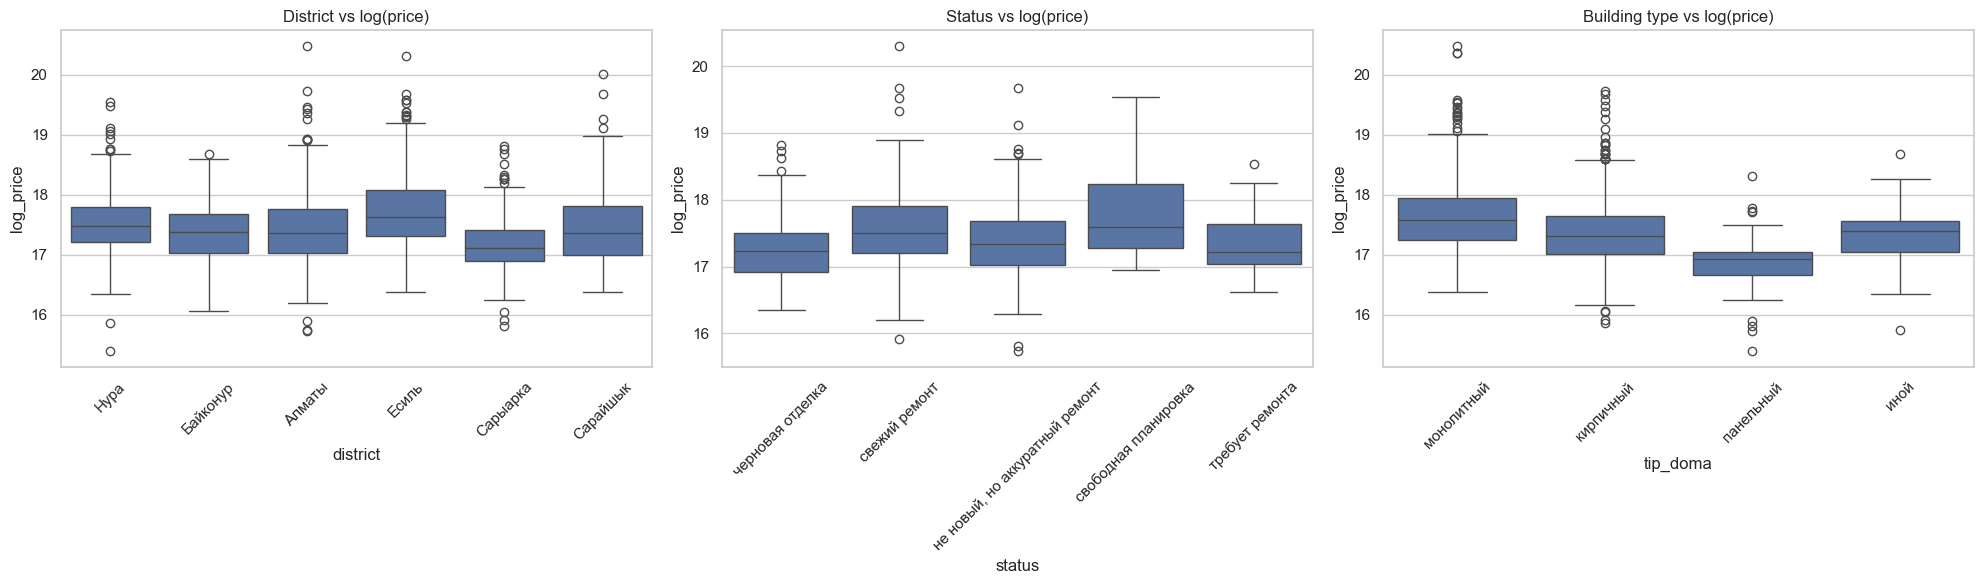

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

top_districts = eda_df["district"].value_counts().head(10).index
sns.boxplot(
    data=eda_df[eda_df["district"].isin(top_districts)],
    x="district",
    y="log_price",
    ax=axes[0]
)
axes[0].set_title("District vs log(price)")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(
    data=eda_df,
    x="status",
    y="log_price",
    ax=axes[1]
)
axes[1].set_title("Status vs log(price)")
axes[1].tick_params(axis="x", rotation=45)

top_building_types = eda_df["tip_doma"].value_counts().head(10).index
sns.boxplot(
    data=eda_df[eda_df["tip_doma"].isin(top_building_types)],
    x="tip_doma",
    y="log_price",
    ax=axes[2]
)
axes[2].set_title("Building type vs log(price)")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

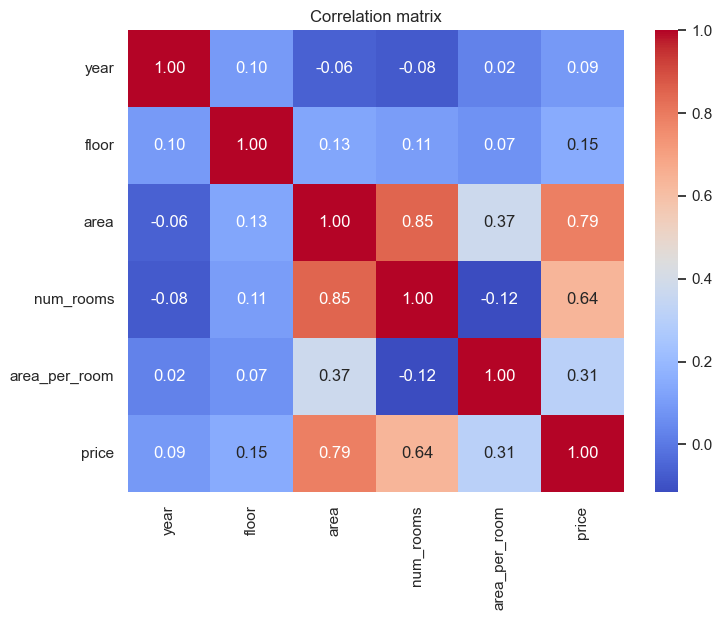

In [8]:
numeric_cols = [
    'year', 'floor', 'area', 'num_rooms', 'area_per_room'
]

corr = eda_df[numeric_cols + ['price']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation matrix')
plt.show()

### EDA observations

Several patterns from the descriptive tables and plots are important for the modeling choices that follow.

- **Price is strongly right-skewed.** The median listing price is 37.5 million tenge, while the mean is much higher at roughly 48.9 million, and the full range extends to 785 million. The histogram of raw price is therefore dominated by a long upper tail rather than a roughly symmetric center.
- **The log transform materially compresses the upper tail.** The log-price histogram is visibly more regular than the raw-price histogram, which supports the later use of a log-transformed target in the regression pipelines.
- **Area is one of the clearest numeric drivers of price.** It has the strongest correlation with price in the heatmap (about 0.79), and the scatterplot shows a clear upward tendency. At the same time, price dispersion grows as area increases, especially among the largest apartments, so a single global linear rule is unlikely to capture the full pattern.
- **Room count is informative but overlaps strongly with area.** Its correlation with price is still substantial (about 0.64), but it is also highly correlated with area (about 0.85), which is exactly the setting in which a regularized linear baseline is useful.
- **Year and floor matter less on their own than size variables.** Their correlations with price are positive but much weaker, and the corresponding scatter shows substantial noise around any simple trend.
- **`area_per_room` adds a useful secondary signal.** Its distribution is concentrated well below the extreme tail seen in raw area, and its relationship with price is positive but weaker than the relationship for total area. This suggests that layout efficiency contains information, but does not dominate overall size.
- **The categorical plots show clear submarket shifts.** Renovation statuses and building types (tip_doma) differ meaningfully in their price distributions. These patterns reinforce the idea that the target is heterogeneous across market segments.
- **The feature set is informative but still limited relative to the target's complexity.** Even the most informative single variables leave substantial within-group spread, which is expected in housing data where exact location, interior quality, seller behavior, and local amenities are not observed directly.

## 4. Train/test split

The cleaned table is divided into training and test sets before model comparison and tuning. The test set is held back until the end of the workflow so that all baseline comparison and hyperparameter search remain confined to the training portion.

With 2,357 cleaned rows, the split produces 1,885 training observations and 472 test observations. The test set is therefore large enough to provide a meaningful final check, while the training set still retains most of the available data for model selection.

In [9]:
X = df[RAW_FEATURE_COLUMNS].copy()
y = df["price"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1885, 10)
Test shape: (472, 10)


## 5. Cross-validation setup and evaluation metrics

Model comparison is performed with cross-validation on the training data. RMSE is treated as the primary selection metric because large pricing errors are especially important in real-estate valuation. MAE is reported alongside RMSE to show typical absolute error, and R² provides a variance-explained view of performance.

A helper evaluation function is also defined for the final holdout stage so that all test metrics are reported on the same original price scale.

In [10]:
cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
}

def evaluate_predictions(y_true, y_pred):
    return {
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

## 6. Baseline model comparison

The baseline stage compares four distinct model families:

- **Dummy median baseline**: a reference point that ignores all predictors and predicts a constant price. This establishes whether the learned models capture real signal rather than merely reflecting the dataset's central tendency.
- **Ridge regression**: a regularized linear model that serves as a strong structured baseline once numeric features are scaled and categorical variables are encoded.
- **Random forest**: a bagged tree model that can capture interactions and threshold effects without assuming linearity.
- **XGBoost**: a boosted tree model that is especially well suited to tabular data with mixed numeric and categorical information after preprocessing.

The EDA already suggests why this comparison is useful. Price increases strongly with area and room count, but the scatterplots also show substantial spread around those trends, and the categorical boxplots reveal clear shifts across districts, building types, and renovation status. That combination indicates that the signal is not purely linear. A linear baseline is still valuable for benchmarking, but a tree-boosting model is a natural candidate because it can represent nonlinear tendencies, interactions, and segment-specific price behavior more flexibly.

In [11]:
candidate_models = {
    "DummyMedian": (DummyRegressor(strategy="median"), False),
    "Ridge": (Ridge(alpha=1.0), True),
    "RandomForest": (
        RandomForestRegressor(
            n_estimators=200,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        False,
    ),
    "XGBoost": (
        XGBRegressor(
            objective="reg:squarederror",
            tree_method="hist",
            n_estimators=350,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.90,
            colsample_bytree=0.80,
            random_state=RANDOM_STATE,
            n_jobs=1,
        ),
        False,
    ),
}

baseline_rows = []
for name, (model, scale_numeric) in candidate_models.items():
    pipe = make_pipeline(model, scale_numeric=scale_numeric)
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    baseline_rows.append(
        {
            "model": name,
            "cv_rmse_mean": -scores["test_rmse"].mean(),
            "cv_rmse_std": scores["test_rmse"].std(),
            "cv_mae_mean": -scores["test_mae"].mean(),
            "cv_r2_mean": scores["test_r2"].mean(),
        }
    )

baseline_results = pd.DataFrame(baseline_rows).sort_values("cv_rmse_mean")
baseline_results

,model,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_r2_mean
2,RandomForest,2.734870e+07,6.985452e+06,1.078319e+07,0.671269
1,Ridge,2.754911e+07,5.823846e+06,1.271416e+07,0.662998
3,XGBoost,2.862918e+07,5.560611e+06,1.063395e+07,0.633896
0,DummyMedian,4.861414e+07,8.345671e+06,2.241772e+07,-0.060715


In [12]:
baseline_log_rows = []
for name, (model, scale_numeric) in candidate_models.items():
    pipe = make_pipeline_log(model, scale_numeric=scale_numeric)
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    baseline_log_rows.append(
        {
            "model": name,
            "cv_rmse_mean": -scores["test_rmse"].mean(),
            "cv_rmse_std": scores["test_rmse"].std(),
            "cv_mae_mean": -scores["test_mae"].mean(),
            "cv_r2_mean": scores["test_r2"].mean(),
        }
    )

baseline_log_results = pd.DataFrame(baseline_log_rows).sort_values("cv_rmse_mean")
baseline_log_results

,model,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_r2_mean
1,Ridge,2.546498e+07,6.361273e+06,1.007832e+07,0.714779
3,XGBoost,2.586178e+07,9.482278e+06,1.014846e+07,0.700182
2,RandomForest,2.718698e+07,8.330750e+06,1.048763e+07,0.677366
0,DummyMedian,4.861414e+07,8.345671e+06,2.241772e+07,-0.060715


### Why the log-target pipelines are kept

The baseline comparison is run twice: once on the original price scale and once with a log-transformed target. This is motivated by the EDA, where price shows a wide range and a long right tail. On the original scale, a relatively small number of very expensive properties can dominate the loss and pull the models toward the extreme upper tail.

The log-target versions improve performance across the learnable model families, which is consistent with that distributional structure. Training on log1p(price) makes the problem more balanced across the full price range and reduces the influence of extreme listings before predictions are converted back to tenge.

A log transformation is also applied to area. Area is positively skewed as well, with a small number of unusually large properties. Logging it reduces skewness, limits the influence of extreme values, and makes its relationship with price easier to model, especially when that relationship is nonlinear rather than strictly proportional.

## 7. Tune the strongest candidate models

The strongest candidates from the baseline stage are tuned with randomized cross-validated search, still using only the training split. Ridge is retained as a compact and interpretable linear benchmark, while XGBoost is retained as the most expressive nonlinear candidate.

In [13]:
xgb_search = RandomizedSearchCV(
    estimator=make_pipeline_log(
        XGBRegressor(
            objective="reg:squarederror",
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=1,
        )
    ),
    param_distributions={
        "model__regressor__n_estimators": randint(250, 650),
        "model__regressor__max_depth": randint(3, 8),
        "model__regressor__learning_rate": loguniform(0.02, 0.12),
        "model__regressor__subsample": uniform(0.75, 0.25),
        "model__regressor__colsample_bytree": uniform(0.70, 0.30),
        "model__regressor__min_child_weight": uniform(1.0, 5.0),
        "model__regressor__reg_alpha": loguniform(1e-5, 1.0),
        "model__regressor__reg_lambda": loguniform(0.3, 5.0),
    },
    n_iter=10,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
    refit=True,
    verbose=0,
)

xgb_search.fit(X_train, y_train)

xgb_best_cv_rmse = -xgb_search.best_score_
xgb_best_params = xgb_search.best_params_

print("Best XGBoost CV RMSE:", round(xgb_best_cv_rmse, 2))
xgb_best_params

Best XGBoost CV RMSE: 25019940.46


{'model__regressor__colsample_bytree': np.float64(0.9976634677873653),
 'model__regressor__learning_rate': np.float64(0.06046777723727943),
 'model__regressor__max_depth': 4,
 'model__regressor__min_child_weight': np.float64(3.6237821581611893),
 'model__regressor__n_estimators': 485,
 'model__regressor__reg_alpha': np.float64(1.304103694341302e-05),
 'model__regressor__reg_lambda': np.float64(1.3131565890620174),
 'model__regressor__subsample': np.float64(0.8499652429288138)}

In [14]:
ridge_search = RandomizedSearchCV(
    estimator=make_pipeline_log(
        Ridge(),
        scale_numeric=True,
    ),
    param_distributions={
        "model__regressor__alpha": loguniform(1e-3, 100.0),
    },
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
    refit=True,
    verbose=0,
)

ridge_search.fit(X_train, y_train)

ridge_best_cv_rmse = -ridge_search.best_score_
ridge_best_params = ridge_search.best_params_

print("Best Ridge CV RMSE:", round(ridge_best_cv_rmse, 2))
ridge_best_params

Best Ridge CV RMSE: 25397438.44


{'model__regressor__alpha': np.float64(4.5705630998014515)}

In [15]:
tuned_cv_results = pd.DataFrame(
    [
        {
            "model": "TunedRidge",
            "cv_rmse_mean": ridge_best_cv_rmse,
            "best_params": ridge_best_params,
        },
        {
            "model": "TunedXGBoost",
            "cv_rmse_mean": xgb_best_cv_rmse,
            "best_params": xgb_best_params,
        },
    ]
).sort_values("cv_rmse_mean")

tuned_cv_results

,model,cv_rmse_mean,best_params
1,TunedXGBoost,2.501994e+07,{'model__regressor__colsample_bytree': 0.99766...
0,TunedRidge,2.539744e+07,{'model__regressor__alpha': 4.5705630998014515}


### Tuned cross-validation comparison

After tuning, the cross-validated RMSE values of the two final candidates are close, but tuned XGBoost has the lower mean RMSE. The margin is not enormous, which means the linear benchmark remains competitive, yet the boosted-tree model edges ahead once nonlinear interactions and threshold behavior are allowed to adjust during tuning.

## 8. Final holdout evaluation

After tuning is completed on the training data, both tuned candidates are evaluated on the untouched test set. This is the first point in the notebook where out-of-sample performance is measured on the holdout split, so these results provide the clearest comparison of the final candidate models on unseen data.

All reported errors remain on the original price scale even though the selected pipelines train on a log-transformed target. This makes the final metrics directly interpretable in tenge.

In [16]:
tuned_models = {
    "TunedRidge": ridge_search.best_estimator_,
    "TunedXGBoost": xgb_search.best_estimator_,
}

test_predictions_map = {}
test_rows = []

for model_name, fitted_model in tuned_models.items():
    preds = fitted_model.predict(X_test)
    test_predictions_map[model_name] = preds
    metrics = evaluate_predictions(y_test, preds)
    test_rows.append({"model": model_name, **metrics})

test_results = pd.DataFrame(test_rows).set_index("model").sort_values("RMSE")
test_results

,RMSE,MAE,MAPE,R2
model,,,,
TunedXGBoost,1.524383e+07,8.712291e+06,0.164137,0.815996
TunedRidge,1.587608e+07,9.479251e+06,0.176985,0.800416


### Holdout test interpretation

On the untouched test split, the tuned XGBoost model achieves the best overall performance: RMSE is about 15.24 million tenge, MAE about 8.71 million, MAPE about 16.4%, and R² about 0.816. Tuned Ridge remains a strong baseline, but it is weaker across all four reported test metrics.

The gap between the two models is consistent with the structure seen earlier in the EDA. The relationship between the available predictors and price is clearly not purely linear: larger apartments show increasing variance, categorical subgroups have different price distributions, and the upper tail is much more heterogeneous than the center of the market. Under those conditions, boosted trees have a natural advantage because they can fit nonlinear tendencies and interactions without requiring them to be specified manually.

## 9. Performance by price segment

A single overall error metric can hide important differences across the price distribution. For that reason, the selected final model is evaluated separately on two test-set segments:

- listings with price at or below the test-set 75th percentile,
- listings above the 75th percentile.

This split is useful because the target distribution is strongly right-skewed. Most listings are concentrated in a much narrower lower-to-mid price range, while the upper tail is much more heterogeneous and contains substantially more expensive apartments.

In [17]:
final_model_name = tuned_cv_results.iloc[0]["model"]
final_model = tuned_models[final_model_name]
test_predictions = test_predictions_map[final_model_name]

q75 = y_test.quantile(0.75)
mask_low = y_test <= q75
mask_high = y_test > q75

segment_results = pd.DataFrame(
    {
        "overall": evaluate_predictions(y_test, test_predictions),
        "<= 75%": evaluate_predictions(y_test[mask_low], test_predictions[mask_low]),
        "> 75%": evaluate_predictions(y_test[mask_high], test_predictions[mask_high]),
    }
)

print("Selected final model by CV:", final_model_name)
segment_results

Selected final model by CV: TunedXGBoost


,overall,<= 75%,> 75%
RMSE,1.524383e+07,7.104220e+06,2.800547e+07
MAE,8.712291e+06,5.152457e+06,1.951349e+07
MAPE,1.641371e-01,1.537951e-01,1.955167e-01
R2,8.159955e-01,5.667431e-01,5.710514e-01


### Segment-level interpretation

The segmented test-set analysis shows why the overall RMSE should not be read as if every part of the market were equally difficult.

- In the current test split, the 75th-percentile threshold is about **58 million tenge**.
- The lower-price segment is relatively concentrated, and that is reflected in its lower errors: RMSE is about **7.10 million** and MAE about **5.15 million**.
- The upper-price segment is far more variable, so its absolute errors are much larger: RMSE is about **28.01 million** and MAE about **19.51 million**.

This should be interpreted in the context of target heterogeneity rather than as a simple failure of the model. In the full cleaned dataset, prices extend to **785 million tenge**, and even in the current test split the upper segment stretches to roughly **286 million**. By contrast, the lower segment is bounded much more tightly. Higher error in the upper segment is therefore expected because the model is being asked to predict a much wider and more uneven price range. The upper tail contains listings that differ not only in scale but also likely in unobserved quality and location factors, making that part of the distribution intrinsically harder to predict.

## 10. XGBoost feature importance

The feature-importance view is inspected for the tuned XGBoost pipeline. In a housing problem with mixed numeric and categorical inputs, feature importance is useful for checking whether the model relies on intuitively relevant variables such as size, room count, district.

These values should be interpreted as model-specific importance rather than as causal effects. They describe how the fitted boosted-tree model distributed predictive usefulness across the transformed feature space.

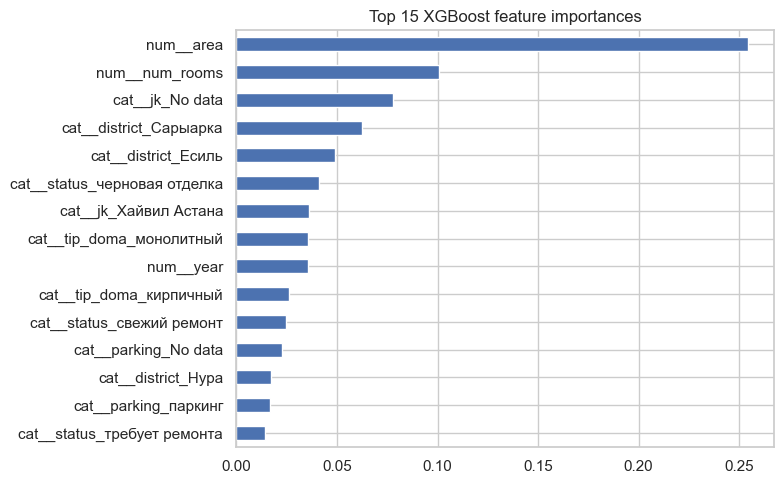

num__area                       0.254589
num__num_rooms                  0.100542
cat__jk_No data                 0.078030
cat__district_Сарыарка          0.062684
cat__district_Есиль             0.049131
cat__status_черновая отделка    0.041295
cat__jk_Хайвил Астана           0.036036
cat__tip_doma_монолитный        0.035432
num__year                       0.035393
cat__tip_doma_кирпичный         0.026172
cat__status_свежий ремонт       0.024458
cat__parking_No data            0.022648
cat__district_Нура              0.017249
cat__parking_паркинг            0.016768
cat__status_требует ремонта     0.014224
dtype: float32

In [18]:
xgb_final_model = xgb_search.best_estimator_
fitted_preprocessor = xgb_final_model.named_steps["preprocess"]
feature_names = fitted_preprocessor.named_steps["column_transformer"].get_feature_names_out()
xgb_regressor = xgb_final_model.named_steps["model"].regressor_
importance = pd.Series(xgb_regressor.feature_importances_, index=feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 5))
importance.sort_values().plot(kind="barh")
plt.title("Top 15 XGBoost feature importances")
plt.tight_layout()
plt.show()

importance

### Interpreting the importance profile

The feature-importance output places total area at the top, followed by room count and a mixture of district, residential-complex, building-type, and status indicators. This is a plausible ranking for the current feature set. 
The result also aligns with the earlier conclusion that housing prices in this dataset are shaped by both continuous scale effects and segment-specific structure.

## 11. Save deployment artifacts

Once the evaluation stage is complete, the selected model family is rebuilt with the best training-side hyperparameters and fit on the full cleaned dataset. This produces a final serialized pipeline together with metadata and a metrics snapshot.

The saved artifact preserves the same preprocessing logic used during evaluation, including feature generation inside the pipeline, encoded categorical handling, and the log-transformed target wrapper.

In [20]:
xgb_best_model_params = {
    key.replace("model__regressor__", ""): value
    for key, value in xgb_best_params.items()
}
ridge_best_model_params = {
    key.replace("model__regressor__", ""): value
    for key, value in ridge_best_params.items()
}

if final_model_name == "TunedRidge":
    deployment_model = make_pipeline_log(
        Ridge(**ridge_best_model_params),
        scale_numeric=True,
    )
    selected_model_params = ridge_best_model_params
    model_family = "Ridge with a log-transformed target and preprocessing pipeline"
else:
    deployment_model = make_pipeline_log(
        XGBRegressor(
            objective="reg:squarederror",
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=1,
            **xgb_best_model_params,
        )
    )
    selected_model_params = xgb_best_model_params
    model_family = "XGBRegressor with a log-transformed target and preprocessing pipeline"

deployment_model.fit(X, y)
joblib.dump(deployment_model, ARTIFACT_DIR / "model_pipeline.pkl")

metadata = build_app_metadata(
    df=df,
    model_family=model_family,
    selected_model_params=selected_model_params,
)

with open(ARTIFACT_DIR / "app_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

metrics_snapshot = {
    "selected_model_by_cv": final_model_name,
    "tuned_cv_results": tuned_cv_results.to_dict(orient="records"),
    "test_results": test_results.reset_index().to_dict(orient="records"),
}

with open(ARTIFACT_DIR / "metrics_snapshot.json", "w", encoding="utf-8") as f:
    json.dump(metrics_snapshot, f, ensure_ascii=False, indent=2)

# print("Saved artifacts to:", ARTIFACT_DIR)
print("Selected deployment model:", final_model_name)

Selected deployment model: TunedXGBoost


## 12. Conclusion

This study models apartment prices from a relatively small structured dataset of 2,357 cleaned listings and a modest set of observable predictors. The available variables capture important broad determinants of price such as size, room count, district, building type, floor, and coarse condition labels, but they do not capture every factor that shapes housing prices in practice. The target therefore remains inherently noisy even under careful preprocessing.

The EDA explains why a transformed-target approach is appropriate. The raw price distribution is strongly right-skewed, with a median of 37.5 million tenge, a mean near 48.9 million, and an upper tail reaching 785 million. Area is also right-skewed, and the scatterplots show that price dispersion widens as apartments become larger and more expensive. In this setting, the log transformation reduces the dominance of extreme observations, stabilizes the scale of the target, and makes the regression problem easier to learn.

The model comparison confirms that the predictors contain substantial signal: all learned models outperform the dummy median baseline by a wide margin. The final tuned comparison shows that boosted trees are especially effective for this task. That result is consistent with the EDA, which shows strong but not purely linear size effects, visible differences across districts and condition categories, and broad heterogeneity in the upper-price range. A regularized linear model remains competitive, but its structure is inherently more limited when price depends on thresholds, interactions, and nonlinear responses.

The final holdout metrics for the selected tuned XGBoost model are strong relative to the scale and limitations of the dataset: RMSE is about 15.24 million tenge, MAE about 8.71 million, MAPE about 16.4%, and R² about 0.816 on the test split. Given the small sample size, the wide price range, and the fact that many important housing determinants are not observed directly, these results are meaningful rather than trivial. They indicate that the available tabular features are sufficient to recover a substantial share of the pricing signal, while still leaving room for further improvement if richer location or property-detail information becomes available.